In [1]:
from cellmender.simulation import simulate_cells
from cellmender.simulation import simple_simulation
import cellmender.utils as cm_utils
from cellmender import denoise_count_matrix, sparse_em
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

cellmender_dir = os.path.dirname(os.path.abspath(""))
out_dir = os.path.join(cellmender_dir, "notebooks", "output", "debug_sim")

/opt/anaconda3/envs/cellmender/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [ ]:
%matplotlib widget

In [3]:
data = simulate_cells(G=10000, N=8000, empty_prob=0.8)

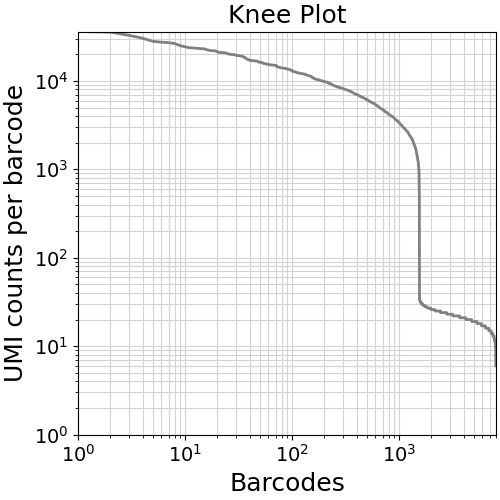

In [4]:
cm_utils.knee_plot(data)

In [5]:
adata_cellmender_path = os.path.join(out_dir, "adata_cellmender.h5ad")
adata_log_path = os.path.join(out_dir, "cellmender.log")


denoised_data = denoise_count_matrix(data, threads=8, adata_out = adata_cellmender_path, log_file = adata_log_path)

Logging to /Users/mcaskey/Desktop/cellmender/notebooks/output/debug_sim/cellmender.log


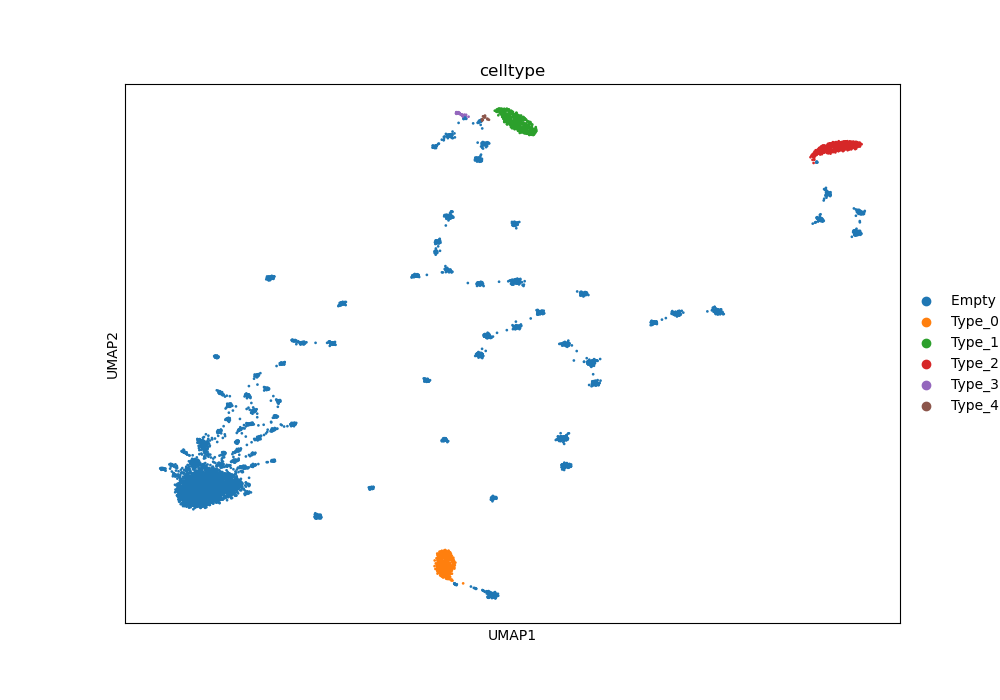

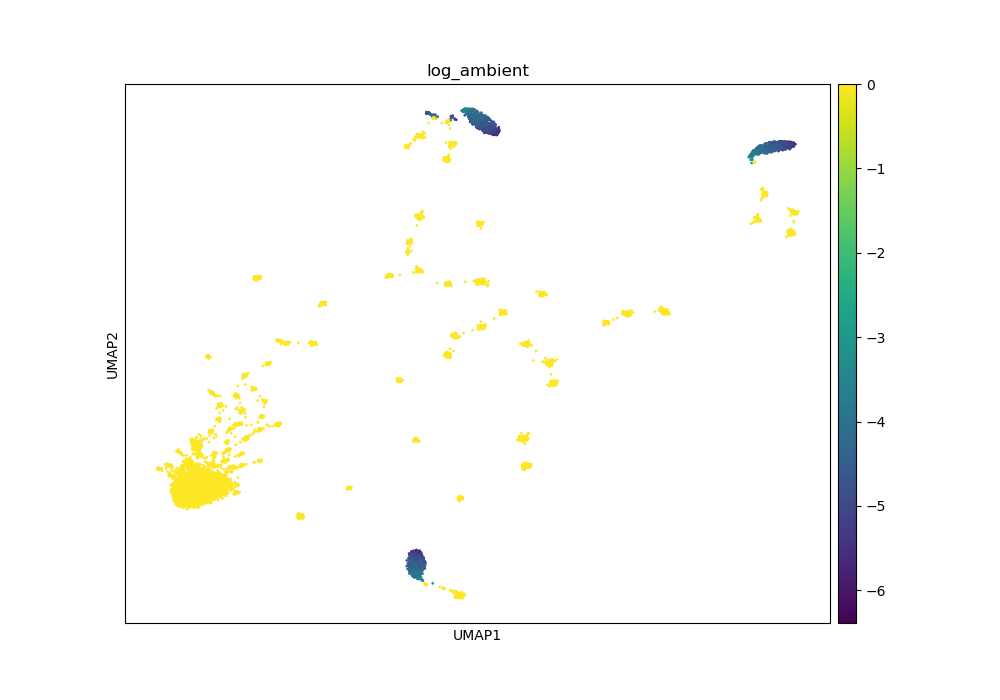

In [6]:
sc.pp.pca(data, n_comps=30)
sc.pp.neighbors(data, n_neighbors=30, n_pcs=30, knn=True)
sc.tl.umap(data)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='celltype', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
data.obs['log_ambient'] = np.log(data.obs['ambient_fraction'])
sc.pl.umap(data, color='log_ambient', ax=ax)

In [7]:
real_mask = ~denoised_data.obs["is_empty"]
print(denoised_data.obs[real_mask])

           cellid celltype  is_empty  ambient_fraction      lib_size  \
Cell_2          1   Type_0     False          0.008826  10769.844446   
Cell_13         2   Type_1     False          0.013309   7020.196873   
Cell_36         3   Type_2     False          0.021265   5301.430253   
Cell_41         2   Type_1     False          0.009647   9654.391176   
Cell_47         2   Type_1     False          0.009074   8863.274881   
...           ...      ...       ...               ...           ...   
Cell_7970       2   Type_1     False          0.008577   8621.253264   
Cell_7973       3   Type_2     False          0.006243  12430.731439   
Cell_7981       2   Type_1     False          0.012129   6292.578014   
Cell_7982       4   Type_3     False          0.010759   8412.954624   
Cell_7995       2   Type_1     False          0.005744  13260.444688   

           cell_ambient_fraction  alpha_hat  z_hat  
Cell_2                       0.9   0.045889      1  
Cell_13                      

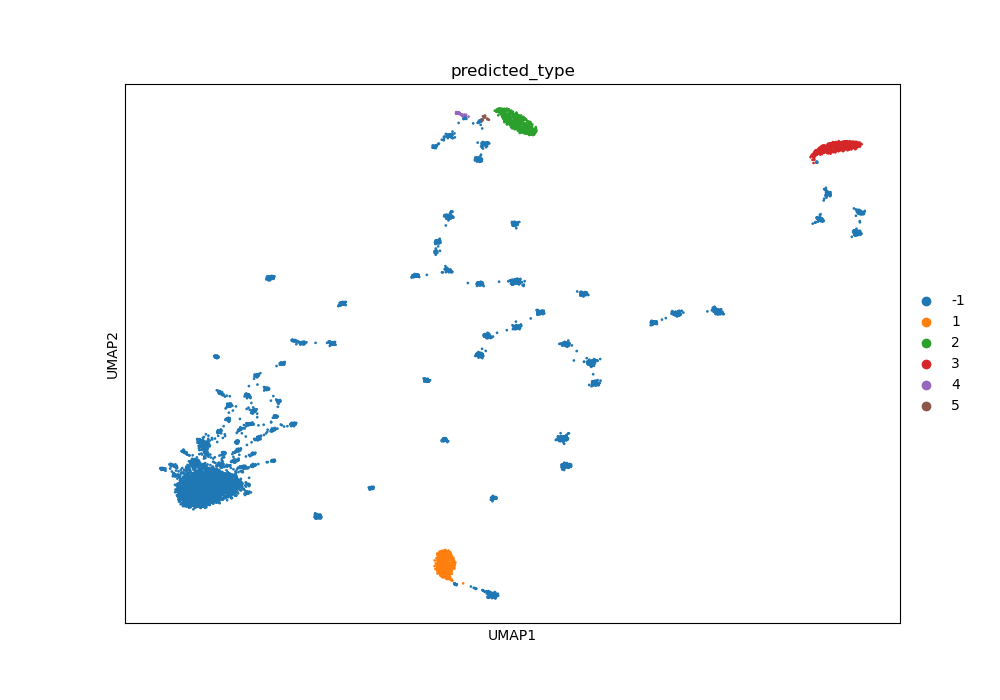

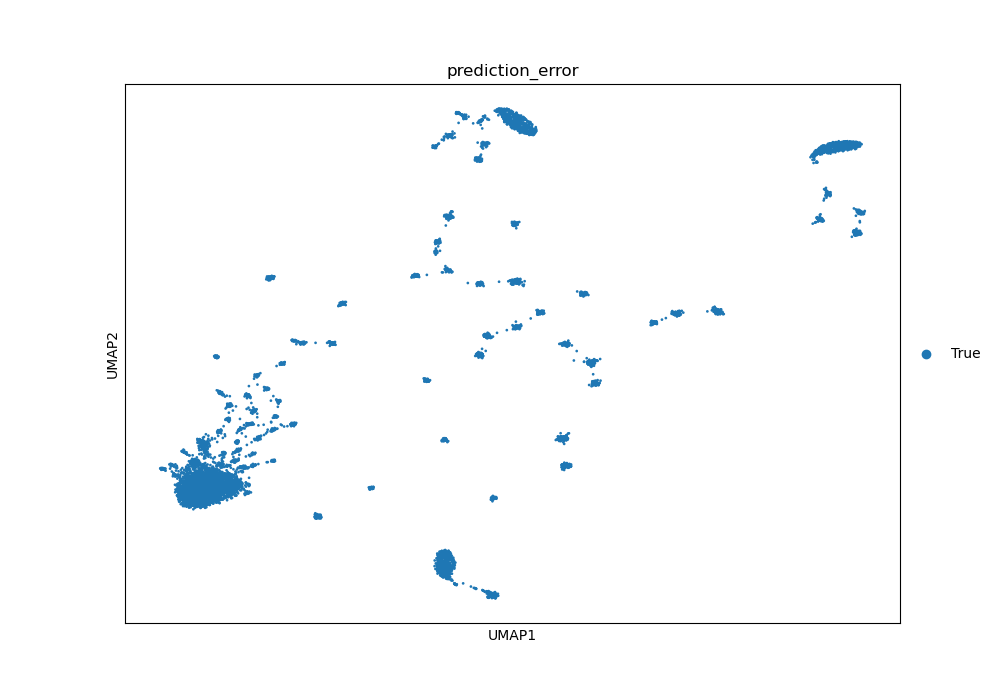

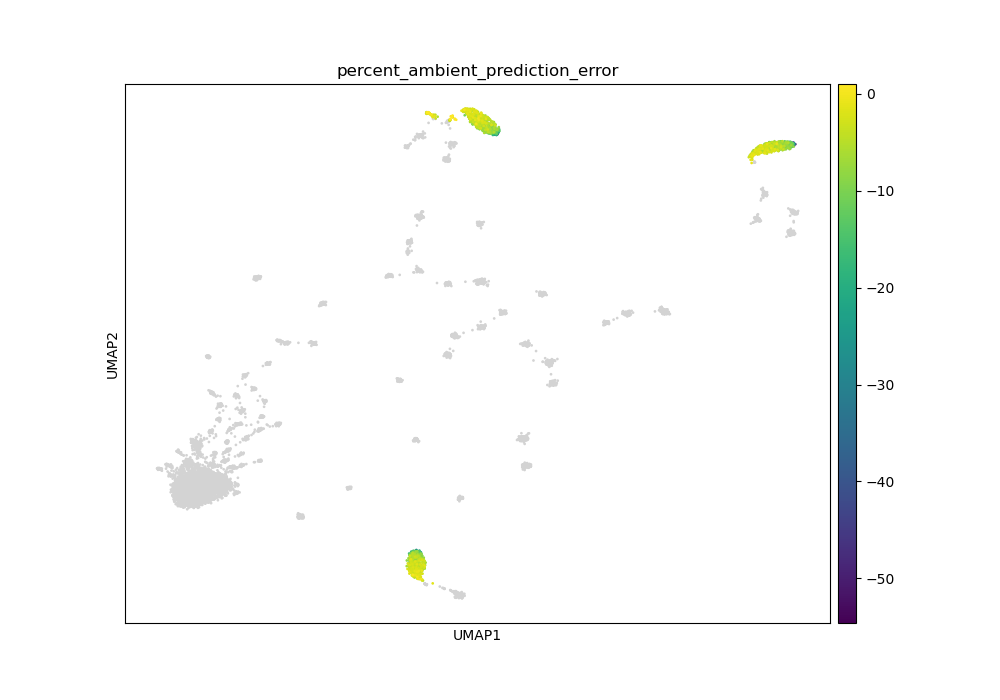

In [8]:
data.obs['percent_ambient_prediction_error'] = (data.obs['ambient_fraction'] - denoised_data.obs['alpha_hat'])/data.obs['ambient_fraction']
data.obs['percent_ambient_prediction_error'] = data.obs['percent_ambient_prediction_error'].mask(~real_mask, np.nan)
data.obs['predicted_type'] = denoised_data.obs['z_hat'].astype('category')
data.obs['prediction_error'] = (denoised_data.obs['z_hat'].astype(int) == denoised_data.obs['cellid'].astype(int))

fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='predicted_type', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='prediction_error',ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='percent_ambient_prediction_error', ax=ax)